# Искусственный интеллект — занятие 3
### Деревья решений: переобучение, обрезка и метод главных компонент

**Логика занятия:** почему дерево решений растёт бесконечно и переобучается → как его ограничивают (обрезка в глубину, ограничение по листьям и по асимметрии классов) → почему обрезка лечит симптом, а не причину → как поворот системы координат превращает сложную границу в одну проверку → метод главных компонент как способ повернуть и сократить пространство признаков.

## Почему дерево нужно обрезать

Решающее дерево растёт до тех пор, пока не разделит обучающую выборку идеально: в каждом листе останутся объекты одного класса. Для выборки из `N` объектов максимальный размер дерева — `2^N - 1` листьев, поэтому на большом датасете оно не влезет ни в память, ни в здравый смысл.

Симптом переобучения — `score` (для `DecisionTreeClassifier` это accuracy) равен `1.0` на обучающих данных при огромном дереве: модель запомнила данные, а не закономерность.

Чтобы ограничить рост, используют методы обрезки (pruning):

1. **Обрезка в глубину** — параметр `max_depth`.
2. **Ограничение по асимметрии разделения** — `min_weight_fraction_leaf`.
3. **Ограничение числа листьев** — `max_leaf_nodes`.

In [23]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [24]:
import numpy as np
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import graphviz
import matplotlib.pyplot as plt

## Параметры обрезки

- `max_depth` — максимальная глубина дерева. Каждый уровень добавляет ещё одну проверку-распил. `max_depth=1` даёт **решающий пень** (см. ниже), `max_depth=7` — уже ограниченное, но полноценное дерево.
- `min_weight_fraction_leaf` — порог по доле класса в листе. Если один класс встречается примерно в 100 раз реже другого, разделение в узле не делается: дерево сразу отдаёт преобладающий класс. Так отсекаются заведомо бесполезные проверки на сильно разбалансированных данных.
- `max_leaf_nodes` — максимальное число листьев, то есть точек, где дерево принимает окончательное решение. `max_leaf_nodes=10` означает: вывод можно сделать только в этих десяти случаях.

При обрезке нижние листья перестают быть чистыми — коэффициент Джини в них не равен нулю. Дойдя до такого листа, дерево выдаёт **класс с максимальной вероятностью** среди попавших в него объектов.

In [25]:


d = []
# with open('files/test_add_short.dat', 'r') as f:
#     for l in f:
#         d.append([float(x) for x in l.split()])

with open('files/source.dat', 'r') as f:
    for l in f:
        d.append([float(x) for x in l.split()])
# Преобразование в массив NumPy
d = np.array(d)

# Разделение на признаки (X) и целевую переменную (y)
x = d[:, :-1]
y = d[:, -1]

# Создание и обучение модели дерева решений
# clf = DecisionTreeClassifier(max_depth=7)
# clf = DecisionTreeClassifier(min_weight_fraction_leaf=0.01)
clf = DecisionTreeClassifier(max_leaf_nodes=10)
clf.fit(x, y)

# Визуализация дерева решений
dot_data = tree.export_graphviz(clf, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("outputs/mytree6")



'outputs/mytree6.pdf'

## Данные и форма границ

`files/source.dat` — три столбца: две координаты объекта и метка класса. Дерево строит проверки вида `x_i > b`, поэтому в двумерном случае все границы разделения идут **перпендикулярно осям**. Сложную наклонную границу дерево вынуждено приближать ступеньками: чем больше глубина, тем больше распилов (`2^depth`) и тем мельче ступеньки.

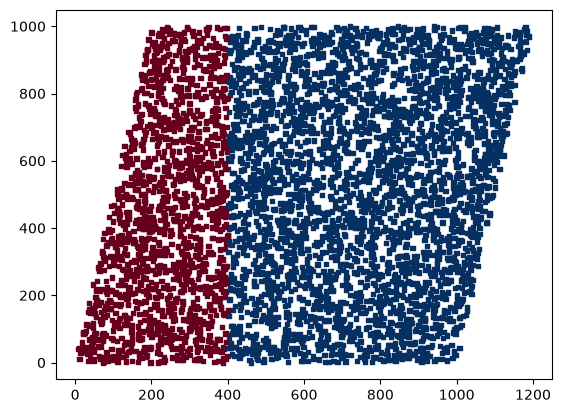

In [34]:
f = open("files/source.dat")
d = []
for s in f:
    d.append([float(x) for x in s.split()]) 

d = np.array(d)
plt.scatter(d[:, 0]+ 0.2*d[:,1], d[:, 1], c=d[:, 2], cmap="RdBu", s = 10, marker='s')


## Поворот системы координат

Причина ветвистости дерева — в самих проверках `x_i > b`: они жёстко привязаны к осям. Если вместо исходных признаков взять их линейную комбинацию, границу можно развернуть под нужным углом:

`y = v0*x0 + v1*x1 + ... + b = <v, x> + b`

Здесь `v` — вектор **нормали** к разделяющей плоскости, `b` — смещение плоскости относительно начала координат. Условие `y > 0` — один класс, `y < 0` — другой. В примере достаточно заменить `x0` на `x0 + 0.2*x1`, и разделение станет перпендикулярно новой оси.

Если к линейной комбинации добавить ступенчатую функцию активации (0 при `y < 0`, 1 при `y > 0`), получится **искусственный нейрон** — базовый элемент нейронной сети. То есть решающий пень с поворотом и нейрон — это одно и то же. Коэффициенты `v` подбирает, например, метод опорных векторов (SVM), который ищет плоскость, перпендикулярную вектору нормали.

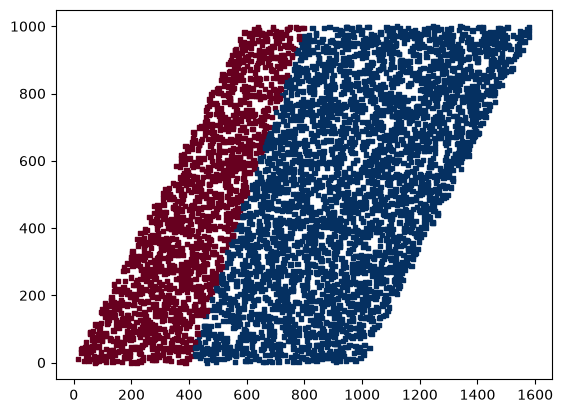

In [38]:
X=d[:,:2]
Y=d[:,2]
X[:,0]=X[:,0]+0.2*X[:,1]
plt.scatter(X[:,0],X[:,1],c=Y,cmap='RdBu',s=10,marker='s')

## Решающий пень (decision stump)

**Решающий пень** — дерево глубины 1: одна проверка больше/меньше порога, на выходе `0` или `1`. Это самый простой классификатор, но если удачно выбрать систему координат, одна проверка даёт почти идеальное разделение (в примере `score` близок к `1`). В коде это `DecisionTreeClassifier(max_depth=1)`.

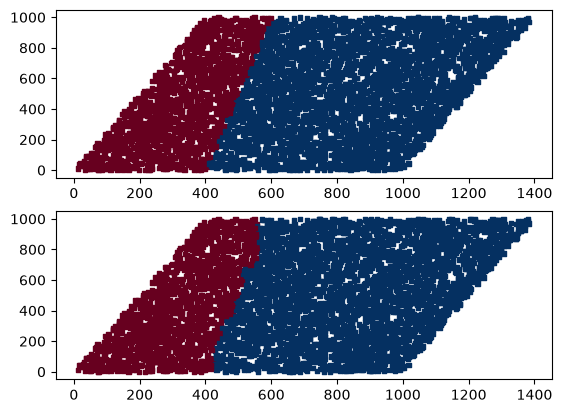

In [37]:
from sklearn.tree import DecisionTreeClassifier
c=DecisionTreeClassifier(max_depth=1)
clf.fit(X,Y)
clf.score(d[:,:2],d[:,2])
Yp=clf.predict(X)
plt.subplot(2,1,1)
plt.scatter(X[:,0],X[:,1],c=d[:,2],cmap='RdBu',s=10,marker='s')
plt.subplot(2,1,2)
plt.scatter(X[:,0],X[:,1],c=Yp,cmap='RdBu',s=10,marker='s')

## Датасет `files/res.txt`

Файл содержит 10 строк по 50 символов `0/1`; по строке нужно определить её номер. Это задача распознавания ZIP-кодов — с неё начинались свёрточные нейронные сети Яна Лекуна. Обычное дерево решает её по нескольким отдельным пикселям и легко сбивается: достаточно изменить один пиксель, и результат меняется. Причина та же — проверки по отдельным осям.

In [45]:
f = open('files/res.txt')
d, y = [], []
for i, s in enumerate(f):
    s=s.replace('\n','')
    d.append([float(x) for x in s])
    y.append(i)
d=np.array(d)
# print(d)
y=np.array(y)
clf=DecisionTreeClassifier()
clf.fit(d, y)
clf.score(d, y)
dot_data = tree.export_graphviz(clf, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("outputs/mytree7")

'outputs/mytree7.pdf'

## Метод главных компонент (PCA)

**Проклятие размерности.** Если число признаков `n` сравнимо с числом объектов `m` или больше него, расстояния между всеми точками становятся примерно одинаковыми, и работать с такими данными нельзя. Признаки избыточны, пространство нужно сокращать.

**Идея метода главных компонент** (он же сингулярное разложение): найти ось, вдоль которой данные растянуты сильнее всего, спроецировать на неё данные, затем в перпендикулярной плоскости снова найти самую длинную ось — и так далее, пока размерность не исчерпается. Каждая новая координата — линейная комбинация всех исходных признаков с подобранными весами: первая компонента самая важная, дальше — всё менее важные.

Датасет `res.txt` имеет форму `10 x 50`, поэтому его ранг не больше 10: PCA даёт ровно 10 ненулевых компонент, а остальные 40 столбцов линейно зависимы и отбрасываются. После поворота и сокращения размерности дерево проверяет уже **комбинации всех 50 пикселей**, а не отдельные пиксели, и распознаёт цифры устойчиво.

- `PCA().fit(X)` — находит направления (главные компоненты).
- `transform(X)` — переводит данные в новую систему координат. В sklearn для преобразования используется `transform`, для предсказания — `predict`.

In [50]:
from sklearn.decomposition import PCA
clf2=PCA()
clf2.fit(d)
print(d.shape)
X2=clf2.transform(d)
print(X2.shape)
# print(X2)
clf=DecisionTreeClassifier()
clf.fit(X2, y)
clf.score(X2, y)

dot_data = tree.export_graphviz(clf, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("outputs/mytree8")

(10, 50)
(10, 10)


'outputs/mytree8.pdf'